In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sys
from statsmodels.formula.api import ols
from scipy import stats

sys.path.append('../')
import ventilation_wall_parameters as vwp

# 対流熱伝達率の近似式の作成

## 分析用データの作成

In [2]:
RECALC = True

詳細計算を行う。

In [3]:
if RECALC:
    df = pd.DataFrame(vwp.get_wall_status_data_by_detailed_calculation("detailed", "detailed"))
    df.to_csv("wall_status_data_frame_detailed.csv")
    print("Results was calculated.")
else:
    df = pd.read_csv('wall_status_data_frame_detailed.csv', index_col=0)
    print("Results was loaded.")


0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
Results was calculated.


データの整形

In [4]:
# 温度差の列を追加
df["delta_theta_as_e-theta_r"] = df["theta_as_e"] - df["theta_r"]
df["delta_theta_sat-theta_r"] = df["theta_sat"] - df["theta_r"]

# 収束しなかった場合のデータを削除する
df = df.query("is_optimize_succeed == True")

# 分析用にメッセージ列を削除
df = df.drop(["is_optimize_succeed", "optimize_message"], axis=1)

# 1つでも欠損値NaNがある行を削除する
df = df[~np.isnan(df).any(axis=1)]

## 冬期条件・夏期条件の計算結果をそれぞれ抽出

冬期条件

In [5]:
df_winter = df.query("theta_e <= 10.0 & theta_r == 20.0")

夏期条件

In [6]:
df_summer = df.query("theta_e >= 25.0 & theta_r == 27.0")

## 対流熱伝達率の要約統計量 

In [7]:
df_winter.loc[:,["h_cv"]].describe(), df_summer.loc[:,["h_cv"]].describe()

(                h_cv
 count  157464.000000
 mean        7.380827
 std         3.728329
 min         1.574063
 25%         4.622736
 50%         6.758345
 75%        10.191417
 max        15.135276,
                 h_cv
 count  177147.000000
 mean        7.469389
 std         4.142821
 min         1.735136
 25%         3.785912
 50%         6.374082
 75%        10.930499
 max        15.905021)

## 作図用の関数の定義

### 散布図（線形回帰式あり）

In [8]:
def setPltSingle(
        df:pd.DataFrame, fig_title:str, x_label:str, y_label:str, x_data_name:str, y_data_name:str, is_fit_intercept:bool,
        xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float
):
    """グラフを描画する（2変数の散布図、線形回帰式あり）
    
    Args:
        df: CSVファイルの全データ
        fig_title: グラフタイトル
        x_label: X軸のラベル
        y_label: Y軸のラベル
        x_data_name: X軸に設定するデータの名称
        y_data_name: Y軸に設定するデータの名称
    """
        
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    
    # フォントサイズを設定
    plt.rcParams["font.size"] = 14

    # グラフタイトルを設定
    fig.suptitle(fig_title)
    
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
    
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    # 描画データ設定
    x = df[x_data_name].to_numpy()
    y = df[y_data_name].to_numpy()

    # 単回帰分析を行う
    res = stats.linregress(x,y)

    # 線形回帰モデルを作成
    a = res.slope
    b = res.intercept
    r2 = res.rvalue ** 2
    
    # 散布図の描画設定
    ax.scatter(x, y, s=30, marker=".")
        
    # 線形近似の描画設定
    ax.plot(x, a*x+b, color="black")

    # 近似式の表示（text関数の引数：x座標、y座標、表示するテキスト）
    ax.text(
        0.95, 0.95,
        'y='+ str(round(a, 3)) +'x+'+str(round(b,3)),
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right'
    )
        
    # 決定係数の表示
    ax.text(
        0.95, 0.9,
        'R2='+ str(round(r2,4)),
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right'
    )
    
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.show()

### ヒストグラム

In [9]:
def setHist(df, fig_title: str):
    fig, ax = plt.subplots(figsize=(6, 4))
    data = df['h_cv']
    counts, bins, patches = ax.hist(
        data,
        bins=25,               # 棒の数（細かさ）
        color='skyblue',       # 棒の色
        edgecolor='black',     # ★ 棒の枠線（これを入れると境界がハッキリします）
        alpha=0.7              # ほんの少し透明にする
    )

    # 4. 補助線の追加（例：平均値のライン）
    mean_val = np.mean(data)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')

    # 5. グラフの装飾
    ax.set_title(fig_title)
    ax.set_xlabel('Convection heat transfer coeff[W/(m2K)]')
    ax.set_ylabel('Frequency (Counts)')
    ax.grid(True, axis='y', linestyle=':', alpha=0.6) # Y軸のみグリッド線を表示
    ax.legend()

    plt.show()

### 簡易法と詳細法との比較

In [10]:
def setPltComparison(fig_title:str, x_label:str, y_label:str, x_data:pd.DataFrame, y_data:pd.DataFrame,
                     xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float):
    
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    # フォントサイズを設定
    plt.rcParams["font.size"] = 14
    
    # グラフタイトルを設定
    fig.suptitle(fig_title)
        
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
        
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
        
    # 描画データ設定
    x = x_data.to_numpy()
    y = y_data.to_numpy()
    
    # 単回帰分析を行う
    res =stats.linregress(x, y)
    
    # 線形回帰モデルを作成
    a = res.slope
    b = res.intercept
    r2 = res.rvalue ** 2
    
    # 散布図の描画設定
    ax.scatter(x, y, s=30, marker=".")

    # 線形グラフの描画設定    
    ax.plot([xlim_min, xlim_max], [ylim_min, ylim_max], color="black")
    
    # 線形近似の描画設定
    ax.plot(x, a*x+b, color="Magenta", linestyle="dashed")
        
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.show()

## 重回帰分析

冬期条件

In [11]:
f = "h_cv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_winter = ols(f, df_winter).fit()
model_winter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_cv   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                 5.832e+04
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:19:35   Log-Likelihood:            -3.0277e+05
No. Observations:              157464   AIC:                         6.056e+05
Df Residuals:                  157452   BIC:                         6.057e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.1260      0.019    533.015      0.000      10.089      10.163
theta_e         -0.0059      0.000    -11.793      0.000      -0.007      -0.005
j_surf           0.0002   9.92e-06     18.743      0.000       0.000       0.000
a_surf           0.1860      0.010     18.743      0.000       0.167       0.205
C_1              0.0038      0.000     36.534      0.000       0.004       0.004
C_2              0.1464      0.002     70.217      0.000       0.142       0.150
l_h             -0.0055      0.001     -4.865      0.000      -0.008      -0.003
l_w          -1.178e-14      0.001  -1.15e-11      1.000      -0.002       0.002
l_d           -282.5458      0.409   -691.354      0.000    -283.347    -281.745
angle           -0.0074      0.000    -64.898      0.000      -0.008      -0.007
v_a              3.9777      0.010    389.315      0.000       3.958       3.998
emissivity_2    -0.3180      0.013    -24.900      0.000      -0.343      -0.293
==============================================================================
Omnibus:                    95899.925   Durbin-Watson:                   0.162
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13772.140
Skew:                          -0.442   Prob(JB):                         0.00
Kurtosis:                       1.851   Cond. No.                     6.27e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.27e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

夏期条件

In [12]:
f = "h_cv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_summer = ols(f, df_summer).fit()
model_summer.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_cv   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                 8.039e+04
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:19:35   Log-Likelihood:            -3.4457e+05
No. Observations:              177147   AIC:                         6.892e+05
Df Residuals:                  177135   BIC:                         6.893e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.9962      0.035    286.784      0.000       9.928      10.065
theta_e          0.0237      0.001     24.066      0.000       0.022       0.026
j_surf           0.0006   9.85e-06     58.392      0.000       0.001       0.001
a_surf           0.5752      0.010     58.392      0.000       0.556       0.594
C_1              0.0038    9.9e-05     38.160      0.000       0.004       0.004
C_2              0.0472      0.002     23.488      0.000       0.043       0.051
l_h             -0.0049      0.001     -4.511      0.000      -0.007      -0.003
l_w           -1.64e-14      0.001  -1.66e-11      1.000      -0.002       0.002
l_d           -331.0666      0.394   -840.277      0.000    -331.839    -330.294
angle           -0.0042      0.000    -38.644      0.000      -0.004      -0.004
v_a              4.0243      0.010    408.564      0.000       4.005       4.044
emissivity_2    -0.2291      0.012    -18.604      0.000      -0.253      -0.205
==============================================================================
Omnibus:                   214013.868   Durbin-Watson:                   0.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            18398.720
Skew:                          -0.496   Prob(JB):                         0.00
Kurtosis:                       1.773   Cond. No.                     6.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 散布図による検証

### 外気温度（theta_e）× 対流熱伝達率（h_cv）

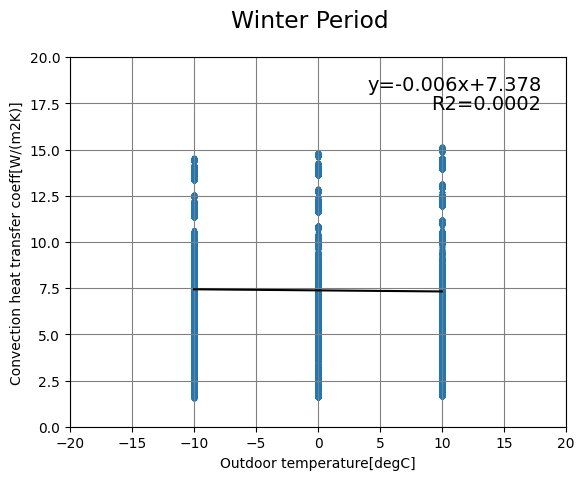

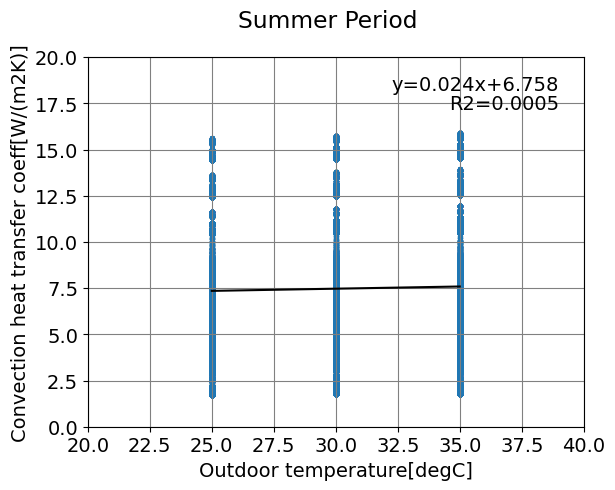

In [13]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -20.0,
       xlim_max = 20.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 20.0,
       xlim_max = 40.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側表面に入射する日射量（j_surf）× 対流熱伝達率（h_cv）

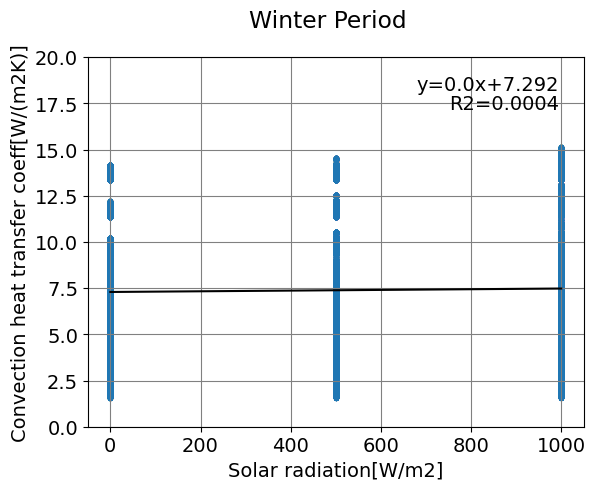

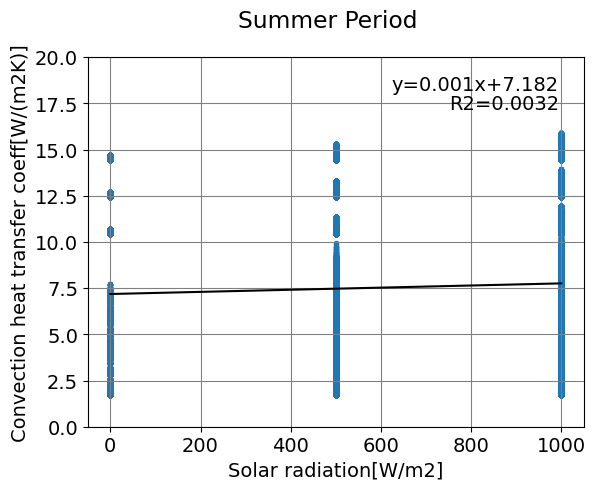

In [14]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側表面日射吸収率（a_surf）× 対流熱伝達率（h_cv）

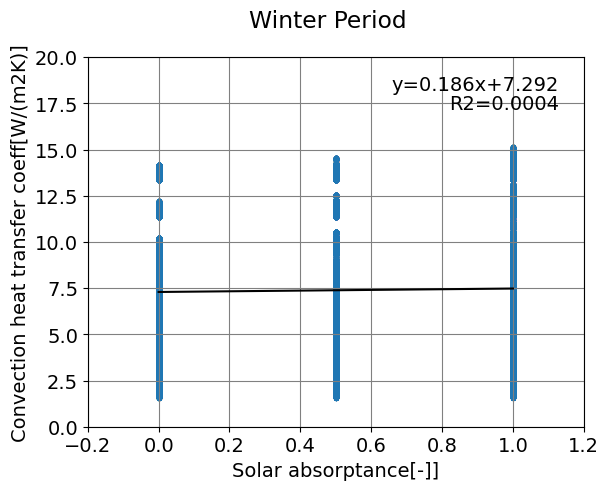

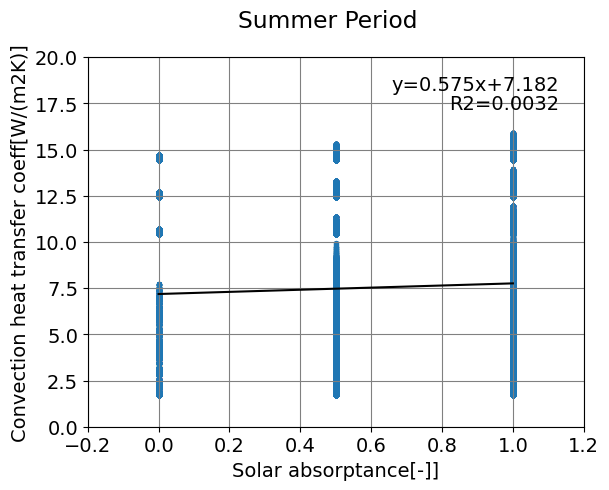

In [15]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側部材の熱コンダクタンス（C_1）× 対流熱伝達率（h_cv）

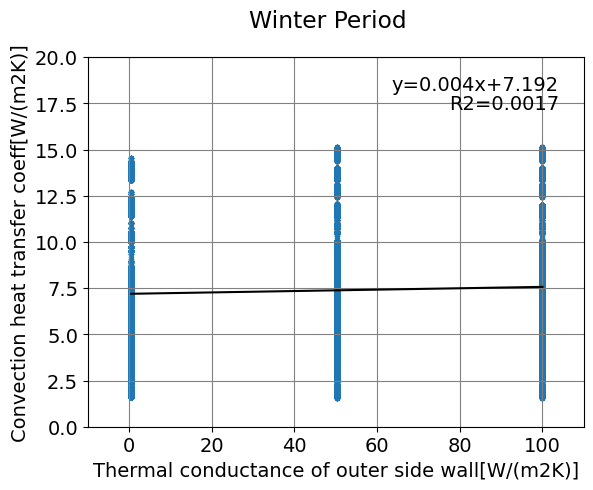

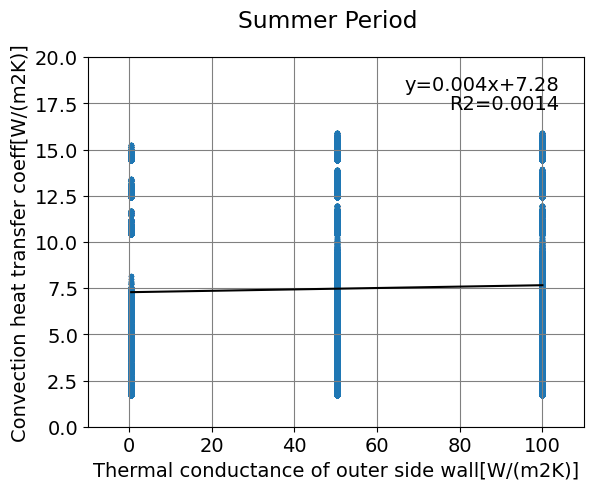

In [16]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 室内側部材の熱コンダクタンス（C_2）× 対流熱伝達率（h_cv）

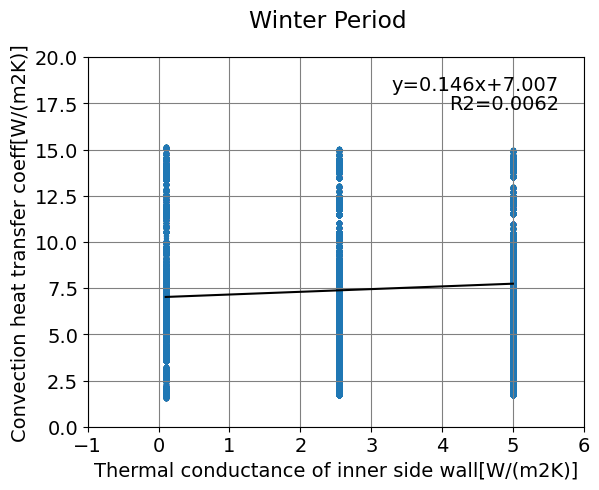

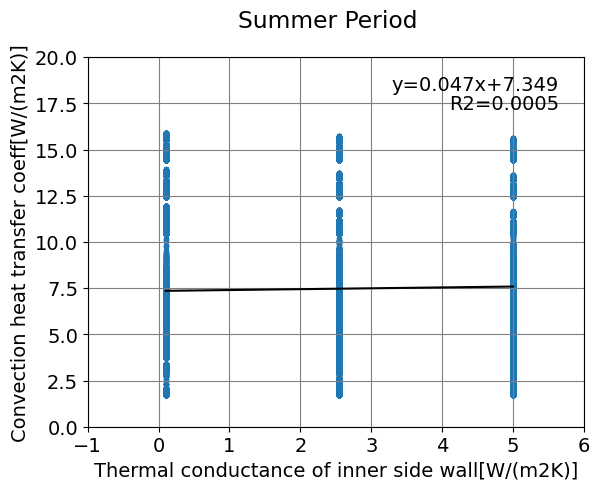

In [17]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -1.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -1.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の長さ（l_h）× 対流熱伝達率（h_cv）

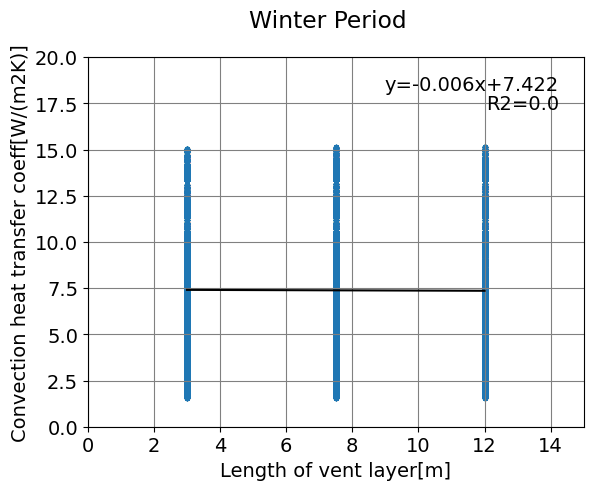

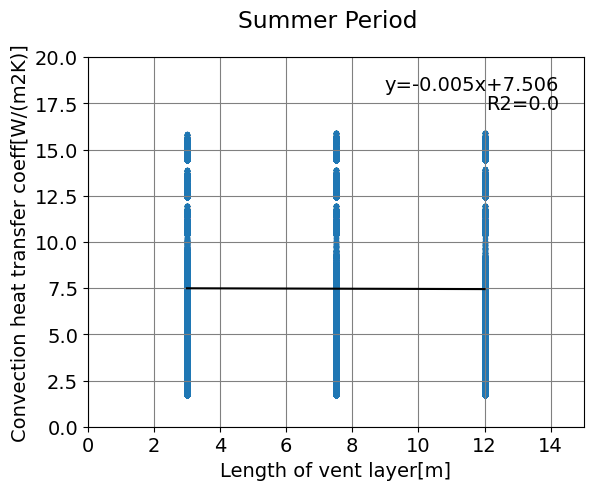

In [18]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Length of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Length of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の厚さ（l_d）× 対流熱伝達率（h_cv）

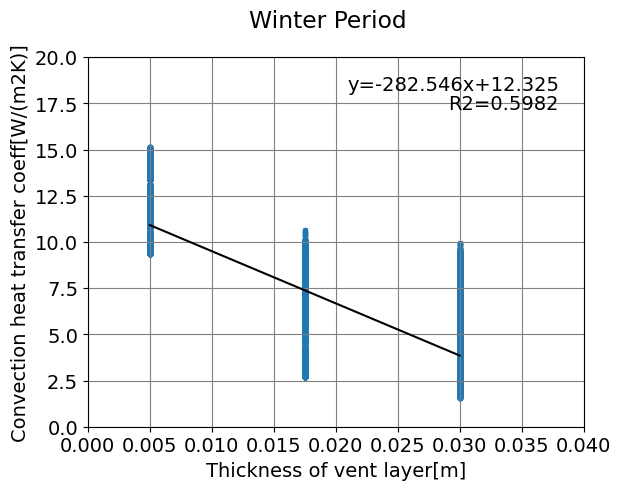

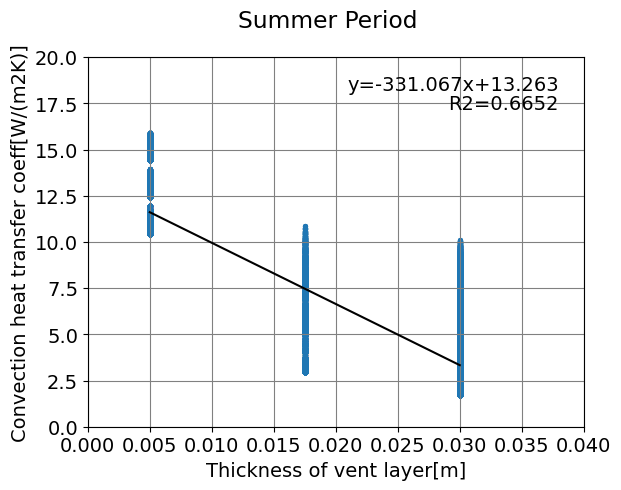

In [19]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の傾斜角（angle）× 対流熱伝達率（h_cv）

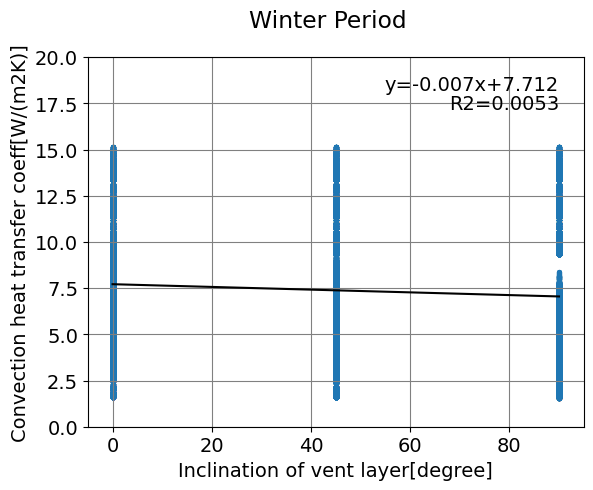

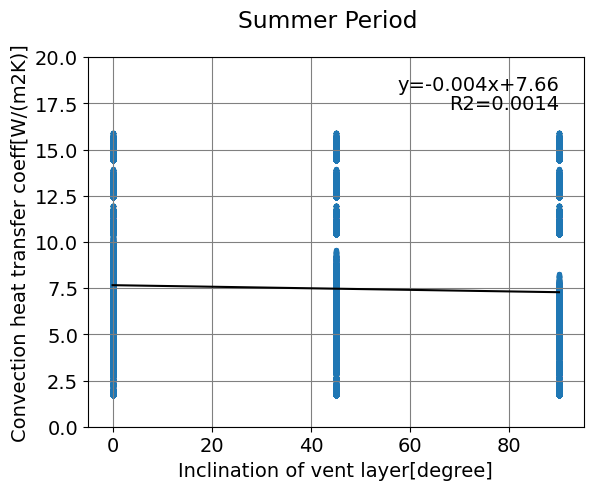

In [20]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Inclination of vent layer[degree]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Inclination of vent layer[degree]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の平均風速（v_a）× 対流熱伝達率（h_cv）

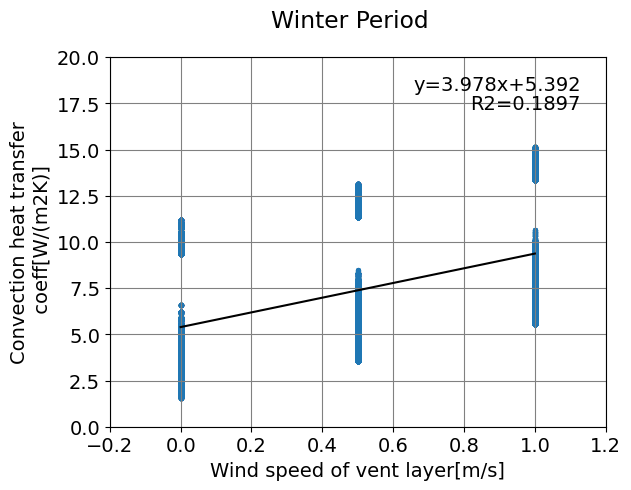

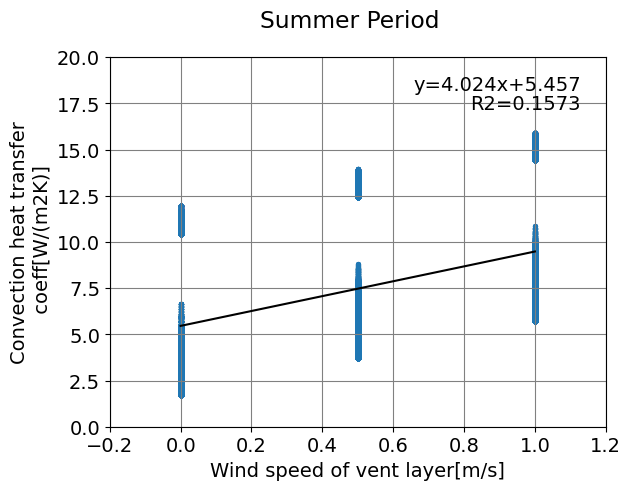

In [21]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層に面する面2の放射率（emissivity_2）× 対流熱伝達率（h_cv）

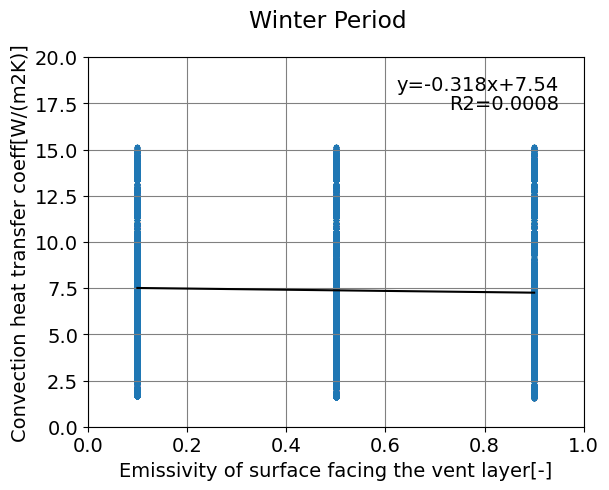

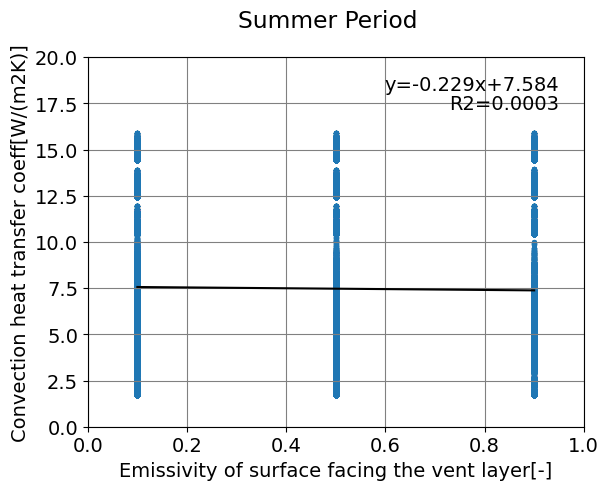

In [22]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

対流熱伝達率に影響を与える要因は、通気層厚さと風速であることが見て取れる。通気層厚さは耐久性等の観点からあまり仕様にばらつきが少ないのに対し、通気層内の風速は季節や地域、日射の有無など外的要因によって大きく変動する。そのため、通気層内の風速を説明変数としてより詳細に解析する。

### 通気層内風速（詳細な解析）

通気層の厚さごとに整理する。

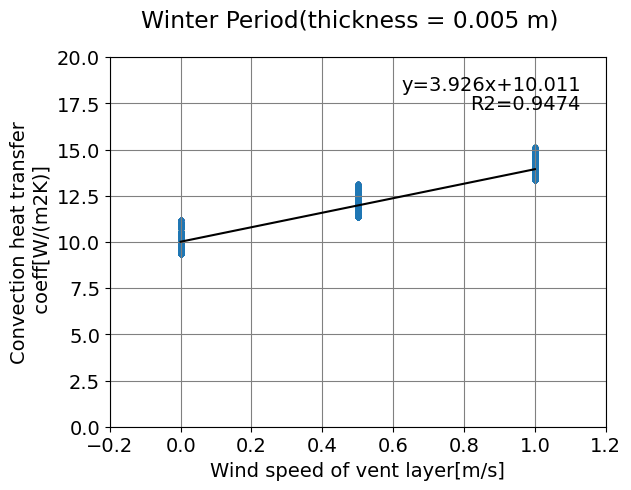

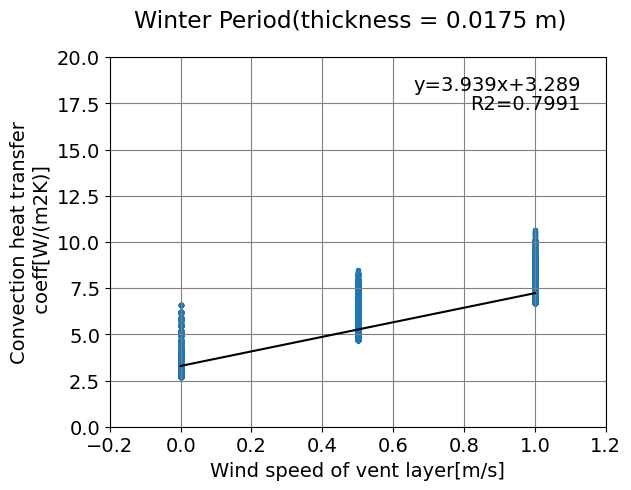

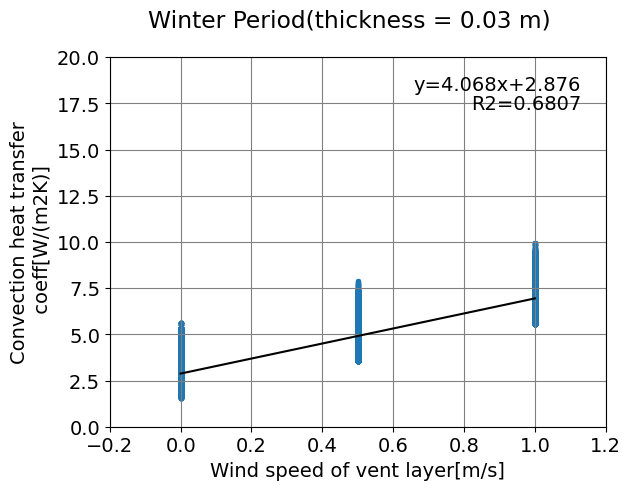

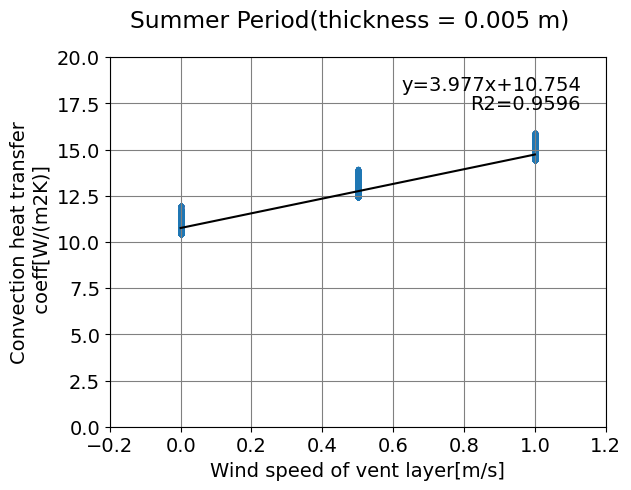

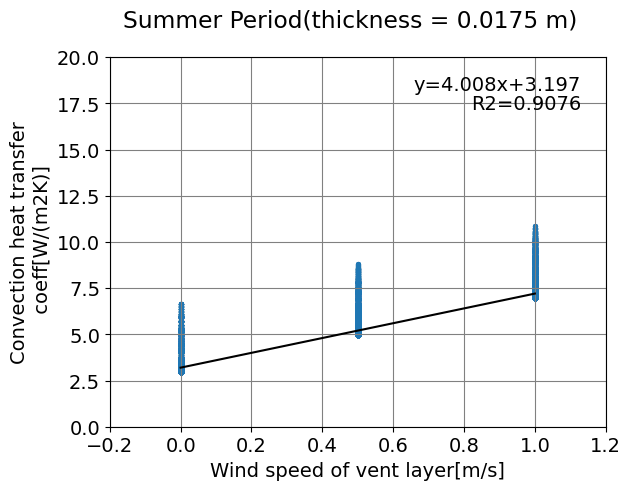

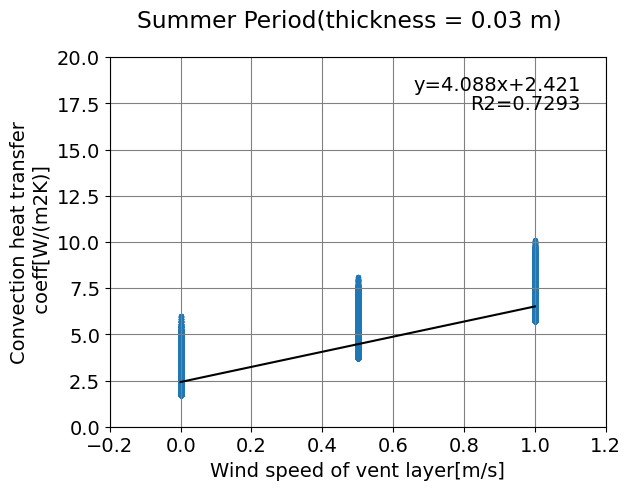

In [23]:
# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.005'),
       fig_title = "Winter Period(thickness = 0.005 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.0175'),
       fig_title = "Winter Period(thickness = 0.0175 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.03'),
       fig_title = "Winter Period(thickness = 0.03 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.005'),
       fig_title = "Summer Period(thickness = 0.005 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.0175'),
       fig_title = "Summer Period(thickness = 0.0175 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.03'),
       fig_title = "Summer Period(thickness = 0.03 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

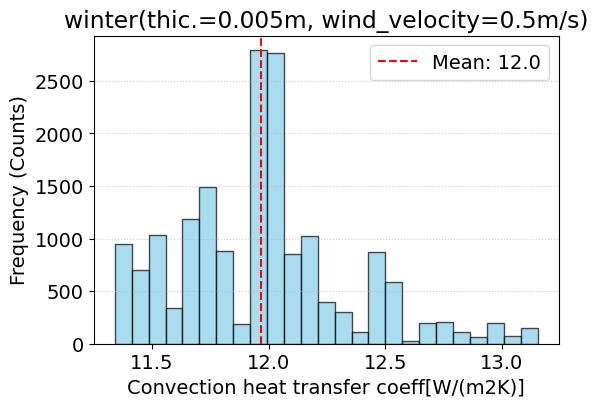

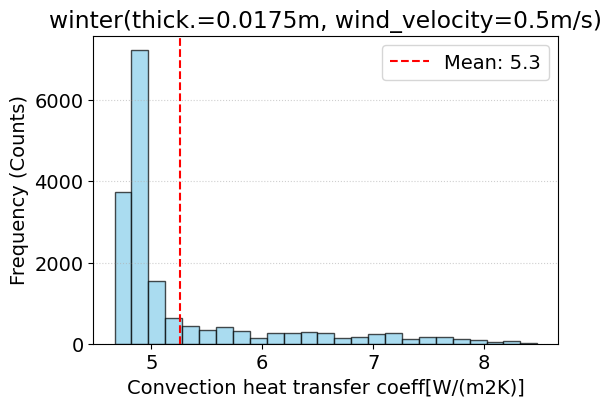

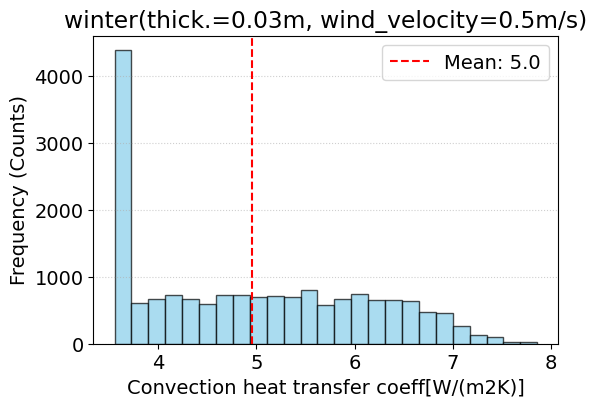

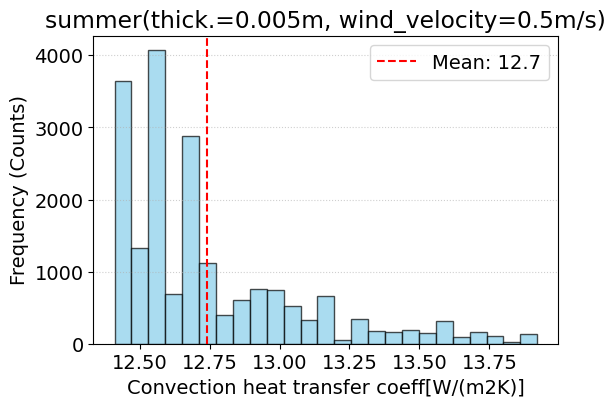

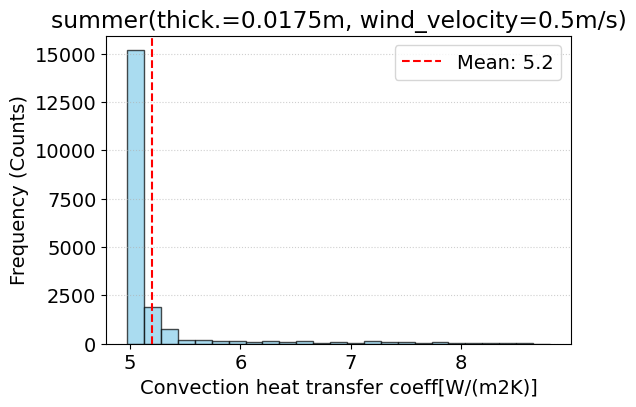

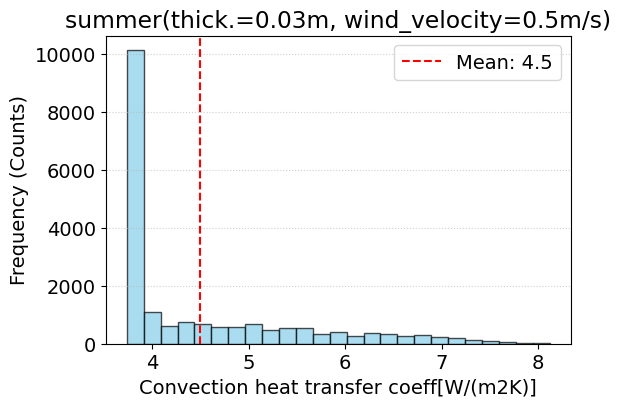

In [24]:
setHist(df=df_winter.query('l_d == 0.005 and v_a == 0.5'), fig_title='winter(thic.=0.005m, wind_velocity=0.5m/s)')
setHist(df=df_winter.query('l_d == 0.0175 and v_a == 0.5'), fig_title='winter(thick.=0.0175m, wind_velocity=0.5m/s)')
setHist(df=df_winter.query('l_d == 0.03 and v_a == 0.5'), fig_title='winter(thick.=0.03m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.005 and v_a == 0.5'), fig_title='summer(thick.=0.005m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.0175 and v_a == 0.5'), fig_title='summer(thick.=0.0175m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.03 and v_a == 0.5'), fig_title='summer(thick.=0.03m, wind_velocity=0.5m/s)')

### 通気層内の角度の影響の確認

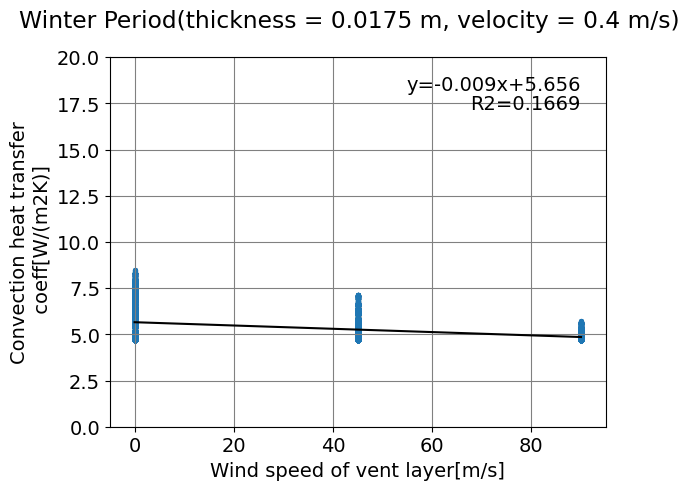

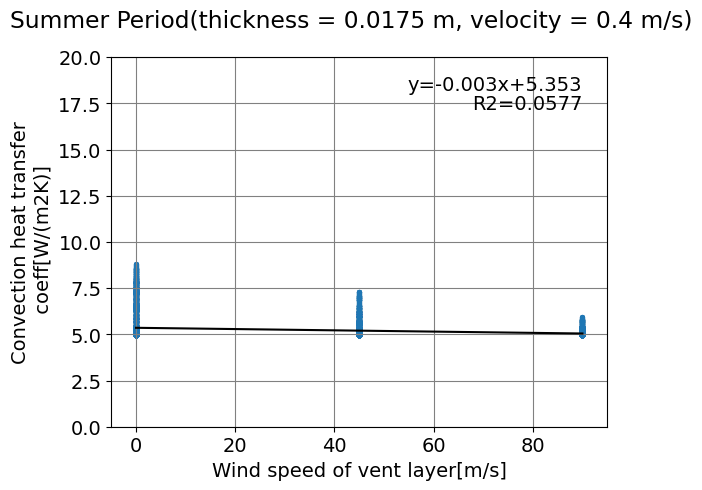

In [25]:
# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.0175 and v_a == 0.5'),
       fig_title = "Winter Period(thickness = 0.0175 m, velocity = 0.4 m/s)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.0175 and v_a == 0.5'),
       fig_title = "Summer Period(thickness = 0.0175 m, velocity = 0.4 m/s)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

## 簡易計算との比較

### 簡易計算

再計算するかどうか

In [26]:
RECALC_W = True
RECALC_S = True

In [27]:
print('winter')
if RECALC_W:
    df_winter_simple = pd.DataFrame(vwp.get_wall_status_data_by_detailed_calculation(calc_mode_h_cv="simplified_winter", calc_mode_h_rv="detailed"))
    df_winter_simple.to_csv("wall_status_data_frame_h_cv_simplified_winter.csv")
    print("Results was calculated.")
else:
    df_winter_simple = pd.read_csv('wall_status_data_frame_h_cv_simplified_winter.csv', index_col=0)
    print("Results was loaded.")

print('summer')
if RECALC_S:
    df_summer_simple = pd.DataFrame(vwp.get_wall_status_data_by_detailed_calculation(calc_mode_h_cv="simplified_summer", calc_mode_h_rv="detailed"))
    df_summer_simple.to_csv("wall_status_data_frame_h_cv_simplified_summer.csv")
    print("Results was calculated.")
else:
    df_summer_simple = pd.read_csv('wall_status_data_frame_h_cv_simplified_summer.csv', index_col=0)
    print("Results was loaded.")

winter
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
Results was calculated.
summer
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
Results was calculated.


### 推定結果の整理

In [28]:
# 冬期・夏期条件の抽出
# 冬期条件
df_winter_simple = df_winter_simple.query("theta_e <= 10.0 & theta_r == 20.0")
# 夏期条件
df_summer_simple = df_summer_simple.query("theta_e >= 25.0 & theta_r == 27.0")

# 収束しなかった場合のデータを削除する
df_winter_simple = df_winter_simple.query("is_optimize_succeed == True")
df_summer_simple = df_summer_simple.query("is_optimize_succeed == True")

# 分析用にメッセージ列を削除
df_winter_simple = df_winter_simple.drop(["is_optimize_succeed", "optimize_message"], axis=1)
df_summer_simple = df_summer_simple.drop(["is_optimize_succeed", "optimize_message"], axis=1)

# 1つでも欠損値NaNがある行を削除する
df_winter_simple = df_winter_simple[~np.isnan(df_winter_simple).any(axis=1)]
df_summer_simple = df_summer_simple[~np.isnan(df_summer_simple).any(axis=1)]

### 対流熱伝達率の計算結果比較（ 簡易計算と詳細計算の結果を比較）

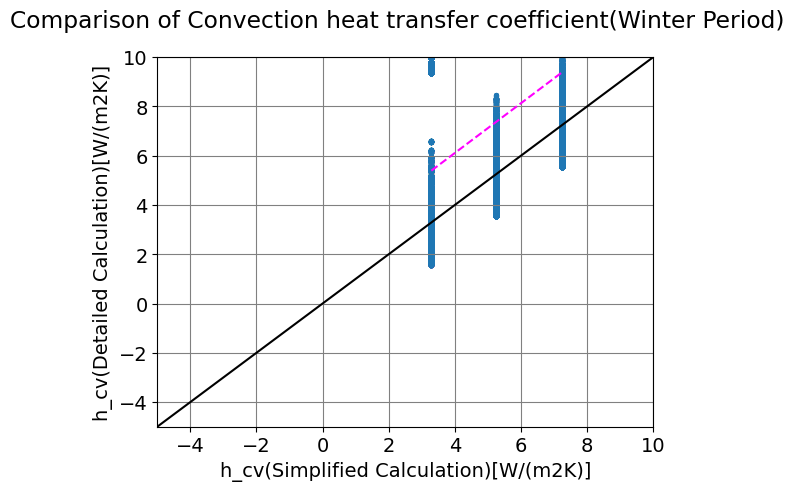

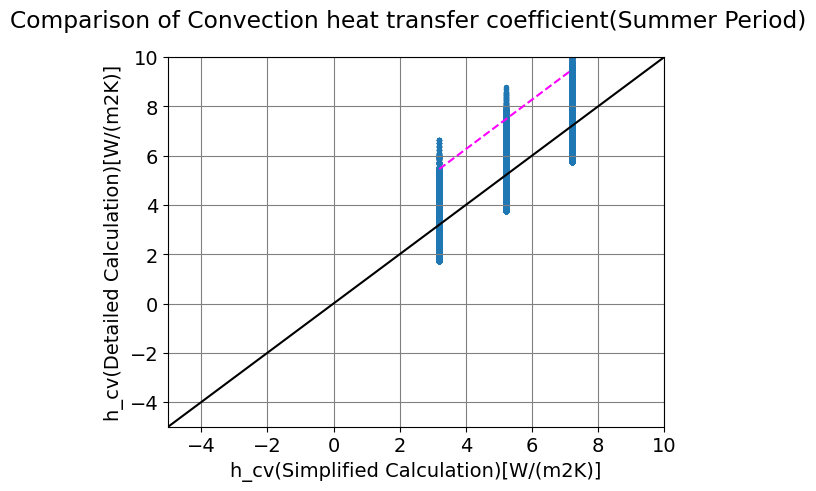

In [29]:
setPltComparison(
       fig_title = "Comparison of Convection heat transfer coefficient(Winter Period)",
       x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
       y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
       x_data = df_winter_simple["h_cv"],
       y_data = df_winter["h_cv"],
       xlim_min = -5.0,
       xlim_max = 10.0,
       ylim_min = -5.0,
       ylim_max = 10.0
      )
setPltComparison(
       fig_title = "Comparison of Convection heat transfer coefficient(Summer Period)",
       x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
       y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
       x_data = df_summer_simple["h_cv"],
       y_data = df_summer["h_cv"],
       xlim_min = -5.0,
       xlim_max = 10.0,
       ylim_min = -5.0,
       ylim_max = 10.0
      )

### 相当熱貫流率の計算結果比較（簡易計算と詳細計算の結果を比較）

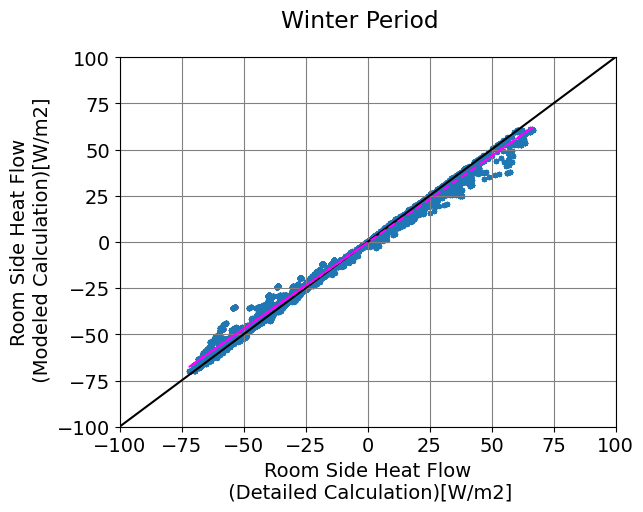

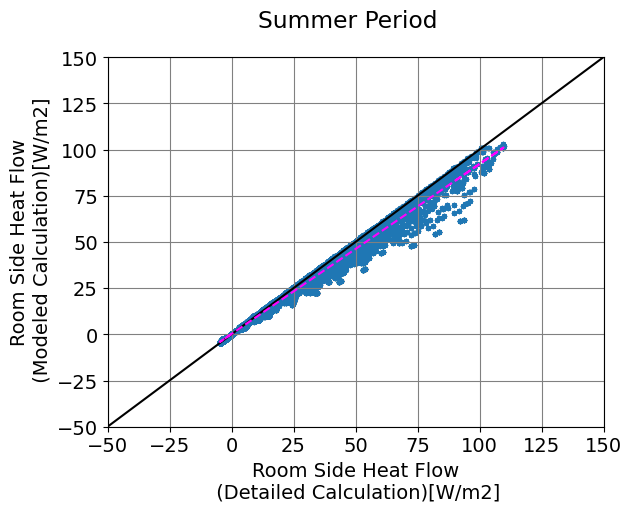

In [31]:
setPltComparison(
       fig_title = "Winter Period",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_winter["q_room_side"],
       y_data = df_winter_simple["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 100.0,
       ylim_min = -100.0,
       ylim_max = 100.0
      )
setPltComparison(
       fig_title = "Summer Period",
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_summer["q_room_side"],
       y_data = df_summer_simple["q_room_side"],
       xlim_min = -50.0,
       xlim_max = 150.0,
       ylim_min = -50.0,
       ylim_max = 150.0
      )